In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [8]:
df=pd.read_csv(r"C:\TSLA.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500
...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400


In [19]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [28]:
df.isnull()


,Date,Open,High,Low,Close,Adj Close,Volume
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
2951,False,False,False,False,False,False,False
2952,False,False,False,False,False,False,False
2953,False,False,False,False,False,False,False
2954,False,False,False,False,False,False,False


In [12]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [9]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB


,Open,High,Low,Close,Adj Close,Volume
count,2956.000000,2956.000000,2956.000000,2956.000000,2956.000000,2.956000e+03
mean,138.691296,141.771603,135.425953,138.762183,138.762183,3.131449e+07
std,250.044839,255.863239,243.774157,250.123115,250.123115,2.798383e+07
min,3.228000,3.326000,2.996000,3.160000,3.160000,5.925000e+05
25%,19.627000,20.402000,19.127500,19.615000,19.615000,1.310288e+07
50%,46.656999,47.487001,45.820002,46.545000,46.545000,2.488680e+07
75%,68.057001,69.357500,66.911501,68.103998,68.103998,3.973875e+07
max,1234.410034,1243.489990,1217.000000,1229.910034,1229.910034,3.046940e+08


In [14]:
df.dropna(axis=0)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-09-29,259.933319,264.500000,256.893341,260.436676,260.436676,62828700
1,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000
2,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200
3,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900
4,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800
...,...,...,...,...,...,...,...
248,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63615400
249,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900
250,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200
251,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800


In [16]:
df.dropna(axis=1)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-09-29,259.933319,264.500000,256.893341,260.436676,260.436676,62828700
1,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000
2,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200
3,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900
4,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800
...,...,...,...,...,...,...,...
248,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63615400
249,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900
250,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200
251,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800


In [20]:
df.dropna(axis=1,inplace=True)

In [24]:
loc=r"C:\Users\aditi\Downloads\archive\TESLA.csv"
df1=pd.read_csv(loc)
df1

,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-09-29,259.933319,264.500000,256.893341,260.436676,260.436676,62828700
1,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000
2,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200
3,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900
4,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800
...,...,...,...,...,...,...,...
248,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63615400
249,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900
250,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200
251,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800


In [26]:
df2=df1.interpolate()
df2

C:\Users\aditi\AppData\Local\Temp\ipykernel_29472\1424639972.py:1: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df2=df1.interpolate()


,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-09-29,259.933319,264.500000,256.893341,260.436676,260.436676,62828700
1,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000
2,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200
3,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900
4,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800
...,...,...,...,...,...,...,...
248,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63615400
249,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900
250,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200
251,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800


In [30]:
df2["Remarks"]=df2["High"]>=270
df2

,Date,Open,High,Low,Close,Adj Close,Volume,Remarks
0,2021-09-29,259.933319,264.500000,256.893341,260.436676,260.436676,62828700,False
1,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,False
2,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,False
3,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,False
4,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,False
...,...,...,...,...,...,...,...,...
248,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63615400,True
249,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,True
250,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,True
251,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,True


In [32]:
df2.dropna(inplace=True)
df2

,Date,Open,High,Low,Close,Adj Close,Volume,Remarks
0,2021-09-29,259.933319,264.500000,256.893341,260.436676,260.436676,62828700,False
1,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,False
2,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,False
3,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,False
4,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,False
...,...,...,...,...,...,...,...,...
248,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63615400,True
249,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,True
250,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,True
251,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,True


In [34]:
ans=df2.groupby("Date")

In [39]:
ans.head(50)

,Date,Open,High,Low,Close,Adj Close,Volume,Remarks
0,2021-09-29,259.933319,264.500000,256.893341,260.436676,260.436676,62828700,False
1,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,False
2,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,False
3,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,False
4,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,False
...,...,...,...,...,...,...,...,...
248,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63615400,True
249,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,True
250,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,True
251,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,True


In [43]:
ans.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume,Remarks
0,2021-09-29,259.933319,264.500000,256.893341,260.436676,260.436676,62828700,False
1,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000,False
2,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200,False
3,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900,False
4,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800,False
...,...,...,...,...,...,...,...,...
248,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63615400,True
249,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900,True
250,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200,True
251,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800,True


In [23]:
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
print(df)

            Date         Open         High         Low        Close  \
0     2010-06-29     3.800000     5.000000    3.508000     4.778000   
1     2010-06-30     5.158000     6.084000    4.660000     4.766000   
2     2010-07-01     5.000000     5.184000    4.054000     4.392000   
3     2010-07-02     4.600000     4.620000    3.742000     3.840000   
4     2010-07-06     4.000000     4.000000    3.166000     3.222000   
...          ...          ...          ...         ...          ...   
2951  2022-03-18   874.489990   907.849976  867.390015   905.390015   
2952  2022-03-21   914.979980   942.849976  907.090027   921.159973   
2953  2022-03-22   930.000000   997.859985  921.750000   993.979980   
2954  2022-03-23   979.940002  1040.699951  976.400024   999.109985   
2955  2022-03-24  1009.729980  1024.489990  988.799988  1013.919983   

        Adj Close    Volume  Target  
0        4.778000  93831500       0  
1        4.766000  85935500       0  
2        4.392000  41094000      

In [25]:
df['MA20'] = df['Close'].rolling(window=20).mean()
df

,Date,Open,High,Low,Close,Adj Close,Volume,Target,MA20
0,2010-06-29,3.800000,5.000000,3.508000,4.778000,4.778000,93831500,0,NaN
1,2010-06-30,5.158000,6.084000,4.660000,4.766000,4.766000,85935500,0,NaN
2,2010-07-01,5.000000,5.184000,4.054000,4.392000,4.392000,41094000,0,NaN
3,2010-07-02,4.600000,4.620000,3.742000,3.840000,3.840000,25699000,0,NaN
4,2010-07-06,4.000000,4.000000,3.166000,3.222000,3.222000,34334500,0,NaN
...,...,...,...,...,...,...,...,...,...
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500,1,832.626996
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200,1,835.835996
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500,1,844.458493
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400,1,856.211993


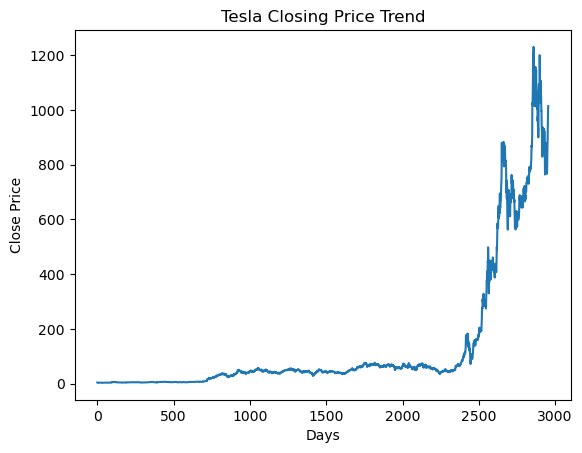

In [11]:
plt.figure()
plt.plot(df['Close'])
plt.title("Tesla Closing Price Trend")
plt.xlabel("Days")
plt.ylabel("Close Price")
plt.show()

<Axes: >

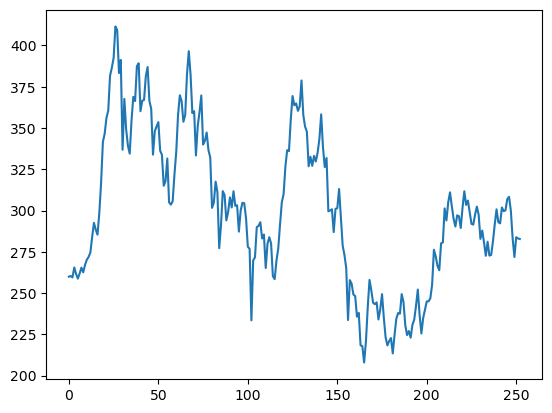

In [105]:
df['Open'].plot()

<Axes: >

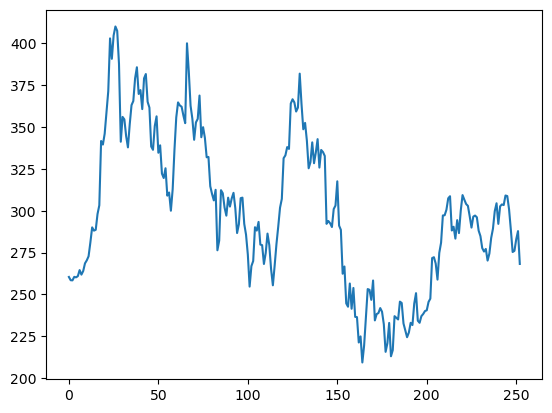

In [107]:
df['Adj Close'].plot()

In [45]:
#so printing top 5 values from top
df.head(5)

,Date,Open,High,Low,Close,Adj Close,Volume
0,2021-09-29,259.933319,264.500000,256.893341,260.436676,260.436676,62828700
1,2021-09-30,260.333344,263.043335,258.333344,258.493347,258.493347,53868000
2,2021-10-01,259.466675,260.260010,254.529999,258.406677,258.406677,51094200
3,2021-10-04,265.500000,268.989990,258.706665,260.510010,260.510010,91449900
4,2021-10-05,261.600006,265.769989,258.066681,260.196655,260.196655,55297800


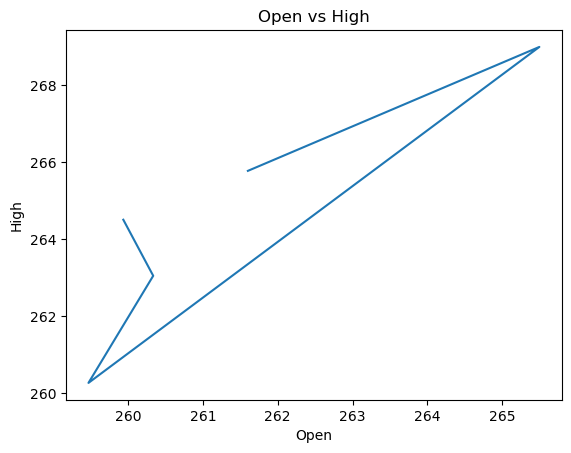

In [57]:
#so ploating on the top 5 data
Open=[259.933319,260.333344,259.466675,265.500000,261.600006]
High=[264.500000,263.043335,260.260010,268.989990,265.769989]
tempo
plt.xlabel("Open")
plt.ylabel("High")
plt.title("Open vs High")
plt.plot(Open,High)


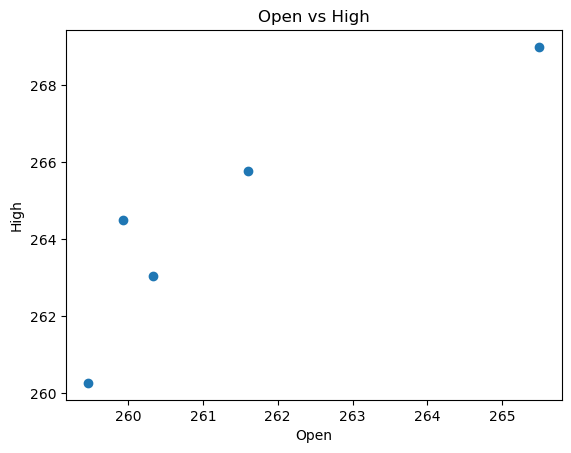

In [77]:
plt.xlabel("Open")
plt.ylabel("High")
plt.title("Open vs High")
plt.scatter(Open,High)

In [73]:
#so printing the values from last
df.tail(10)

,Date,Open,High,Low,Close,Adj Close,Volume
243,2022-09-16,299.609985,303.709991,295.600006,303.350006,303.350006,86949500
244,2022-09-19,300.089996,309.839996,297.799988,309.070007,309.070007,60231200
245,2022-09-20,306.910004,313.329987,305.579987,308.730011,308.730011,61642800
246,2022-09-21,308.290009,313.799988,300.630005,300.799988,300.799988,62555700
247,2022-09-22,299.859985,301.290009,285.820007,288.589996,288.589996,70545400
248,2022-09-23,283.089996,284.500000,272.820007,275.329987,275.329987,63615400
249,2022-09-26,271.829987,284.089996,270.309998,276.010010,276.010010,58076900
250,2022-09-27,283.839996,288.670013,277.510010,282.940002,282.940002,61925200
251,2022-09-28,283.079987,289.000000,277.570007,287.809998,287.809998,54664800
252,2022-09-29,282.760010,283.649994,265.779999,268.209991,268.209991,77393100


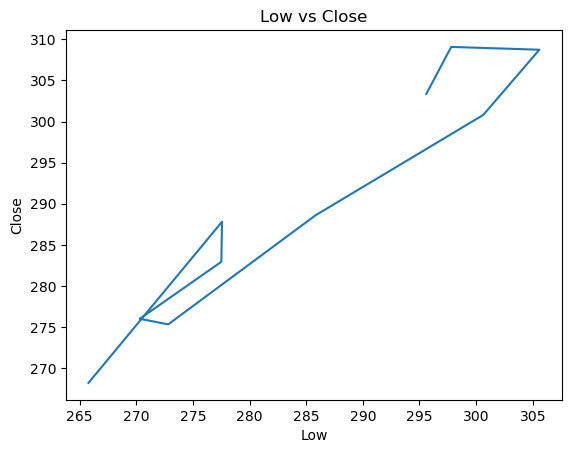

In [75]:
Low=[295.600006,297.799988,305.579987,300.630005,285.820007,272.820007,	270.309998,277.510010,277.570007,265.779999]
Close=[303.350006,309.070007,308.730011,300.799988,288.589996,275.329987,276.010010,282.940002,287.809998,268.209991]
df_sales=pd.DataFrame({"Low":Low,"Close":Close})
df_sales
plt.xlabel("Low")
plt.ylabel("Close")
plt.title("Low vs Close")
plt.plot(Low,Close)

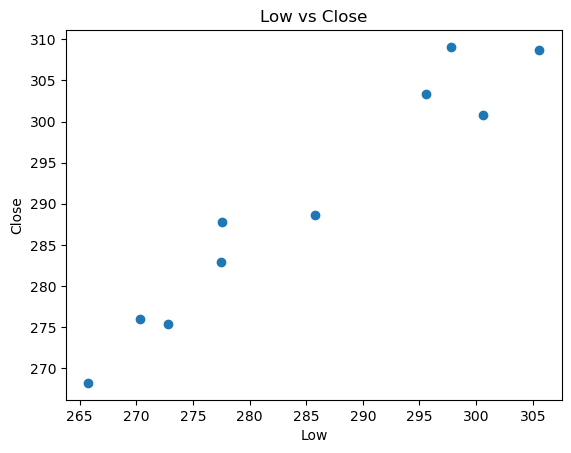

In [79]:
plt.xlabel("Low")
plt.ylabel("Close")
plt.title("Low vs Close")
plt.scatter(Low,Close)

In [81]:
df["Adj Close"].unique()

array([260.436676, 258.493347, 258.406677, 260.51001 , 260.196655,
       260.916656, 264.536682, 261.829987, 263.980011, 268.573334,
       270.359985, 272.773346, 281.01001 , 290.036682, 288.089996,
       288.600006, 298.      , 303.226654, 341.619995, 339.476654,
       345.953339, 359.013336, 371.333344, 402.863342, 390.666656,
       404.619995, 409.970001, 407.363342, 387.646667, 341.166656,
       355.983337, 354.503326, 344.473328, 337.796661, 351.57666 ,
       363.003326, 365.459991, 379.019989, 385.623322, 369.676666,
       372.      , 360.640015, 378.996674, 381.58667 , 365.      ,
       361.533325, 338.323334, 336.33667 , 350.583344, 356.320007,
       334.600006, 339.01001 , 322.136658, 319.503326, 325.329987,
       308.973328, 310.856659, 299.980011, 312.843323, 336.290009,
       355.666656, 364.646667, 362.823334, 362.063324, 356.779999,
       352.26001 , 399.926666, 383.196655, 362.706665, 354.899994,
       342.320007, 352.706665, 354.799988, 368.73999 , 343.853

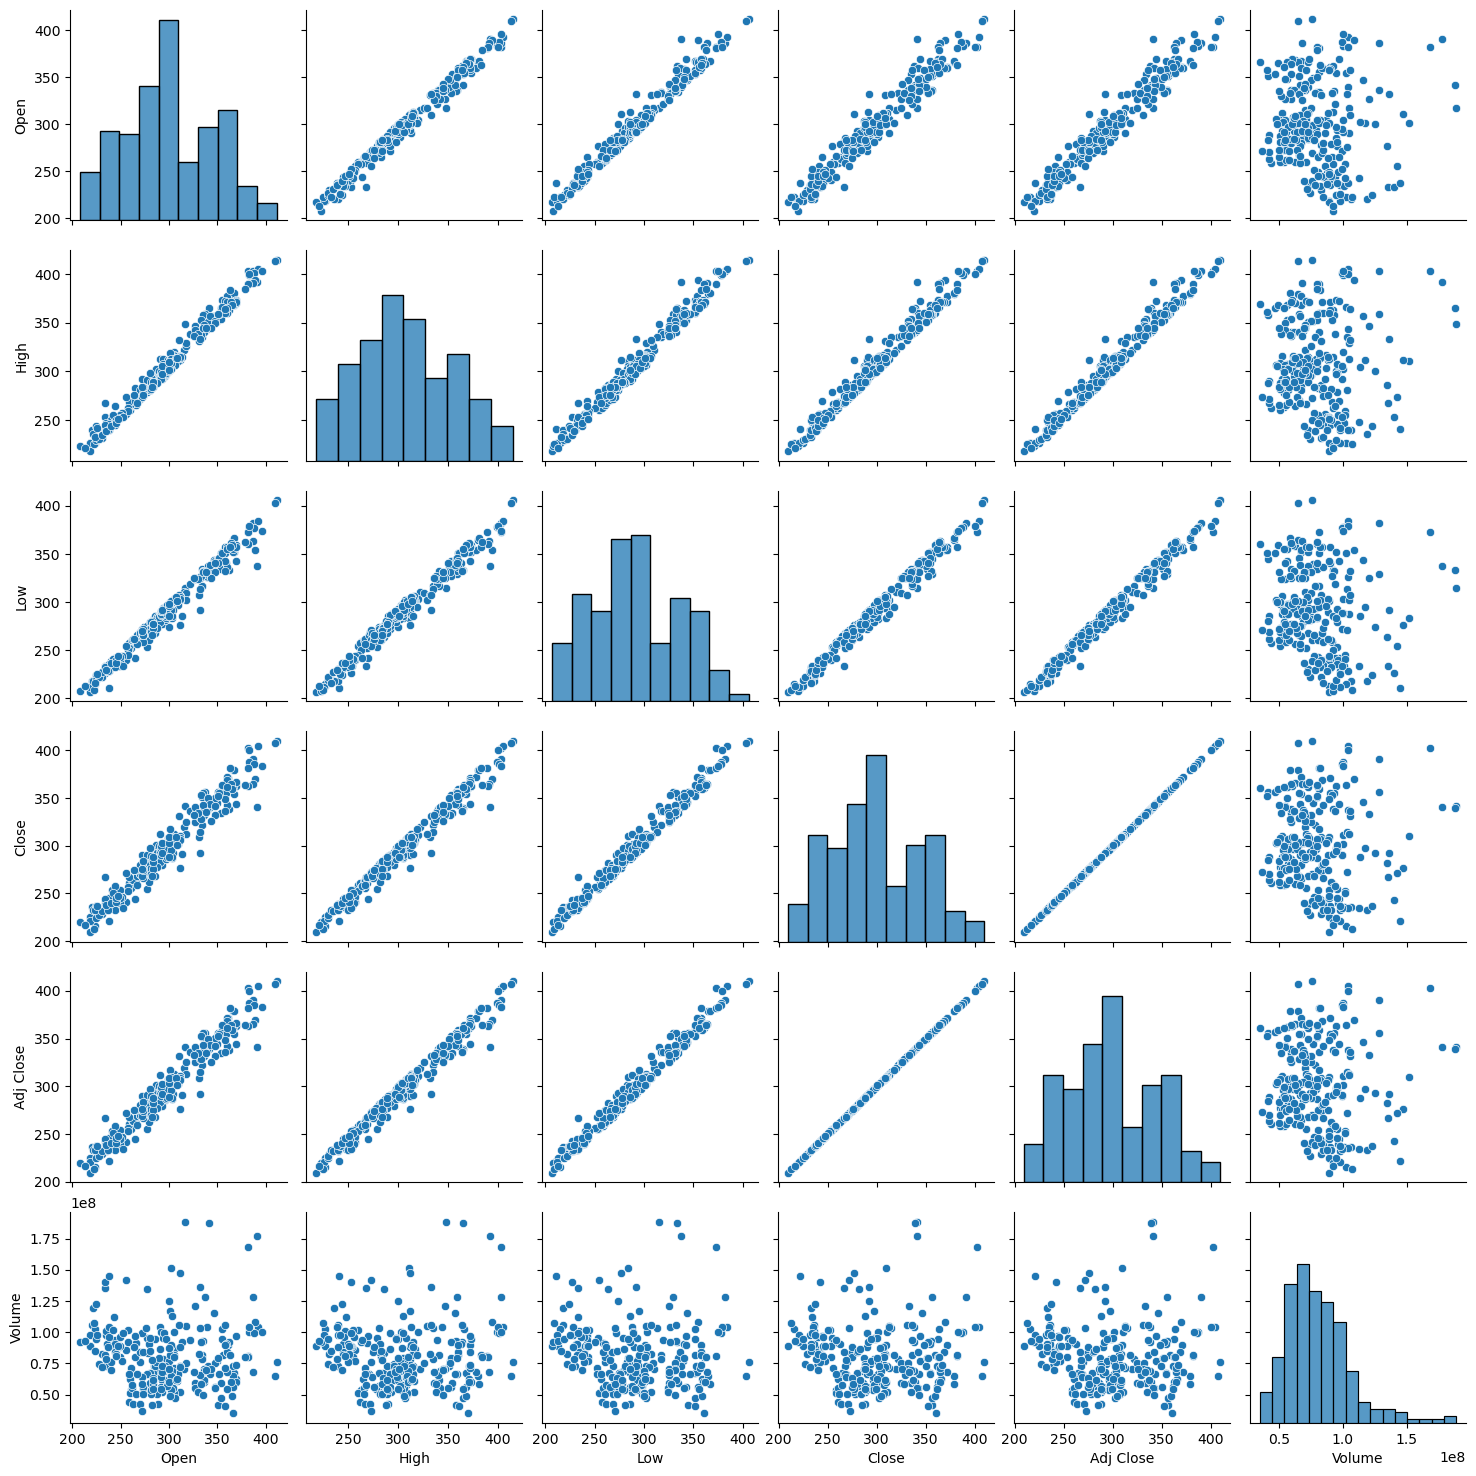

In [7]:
import seaborn as sns
sns.pairplot(df)

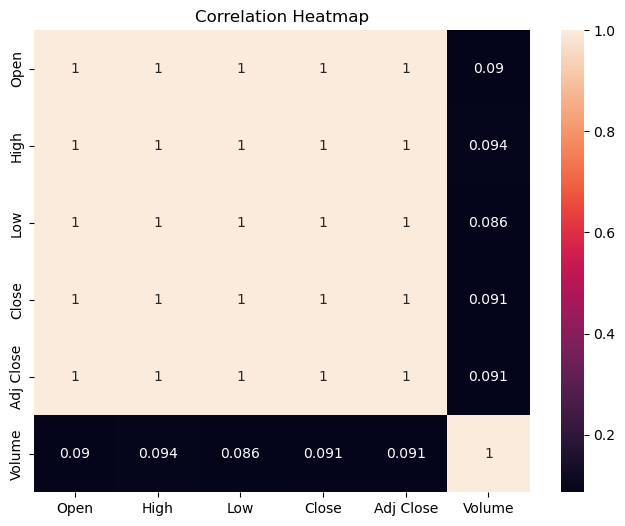

In [13]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

In [85]:
x=df.iloc[:,1:6]
x

,Open,High,Low,Close,Adj Close
0,259.933319,264.500000,256.893341,260.436676,260.436676
1,260.333344,263.043335,258.333344,258.493347,258.493347
2,259.466675,260.260010,254.529999,258.406677,258.406677
3,265.500000,268.989990,258.706665,260.510010,260.510010
4,261.600006,265.769989,258.066681,260.196655,260.196655
...,...,...,...,...,...
248,283.089996,284.500000,272.820007,275.329987,275.329987
249,271.829987,284.089996,270.309998,276.010010,276.010010
250,283.839996,288.670013,277.510010,282.940002,282.940002
251,283.079987,289.000000,277.570007,287.809998,287.809998


In [91]:
y=df.iloc[:,6:]
y

,Volume
0,62828700
1,53868000
2,51094200
3,91449900
4,55297800
...,...
248,63615400
249,58076900
250,61925200
251,54664800


C:\Users\aditi\AppData\Local\Temp\ipykernel_9644\670245245.py:1: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df["Adj Close"], color = "blue", shade = True)


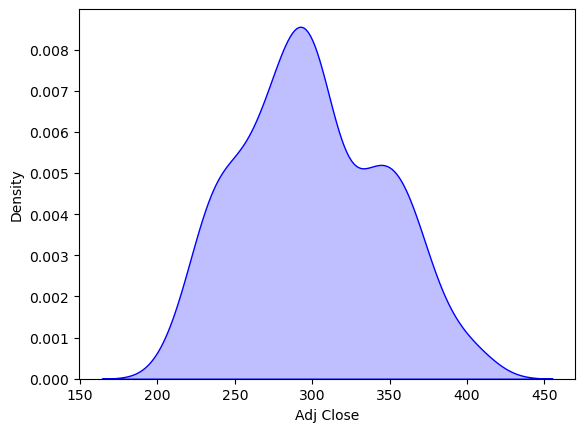

<Figure size 640x480 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [12]:
sns.kdeplot(df["Adj Close"], color = "blue", shade = True)
plt.show()
plt.figure()

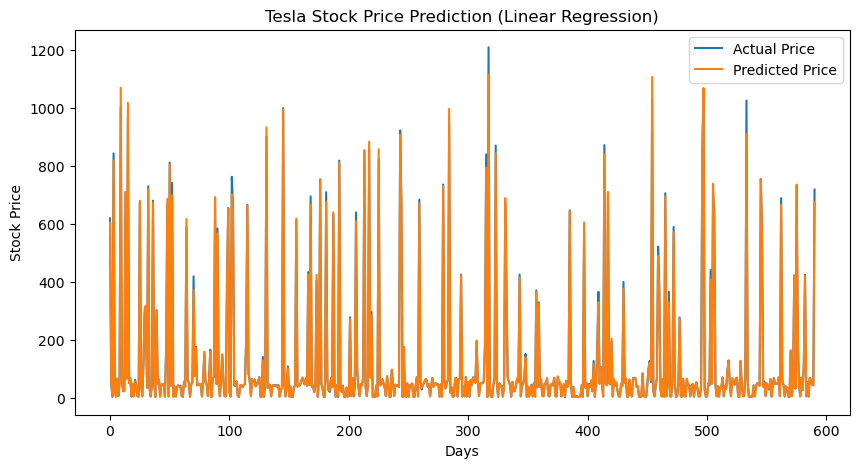

In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
predictions = model.predict(X_test)

# Plot
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.xlabel("Days")
plt.ylabel("Stock Price")
plt.title("Tesla Stock Price Prediction (Linear Regression)")
plt.legend()
plt.show()


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


In [21]:
df['Target'] = np.where(df['Close'].shift(-1) > df['Close'], 1, 0)
X = df[['Open', 'High', 'Low', 'Close', 'Volume']]
y = df['Target']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.49492671927846676


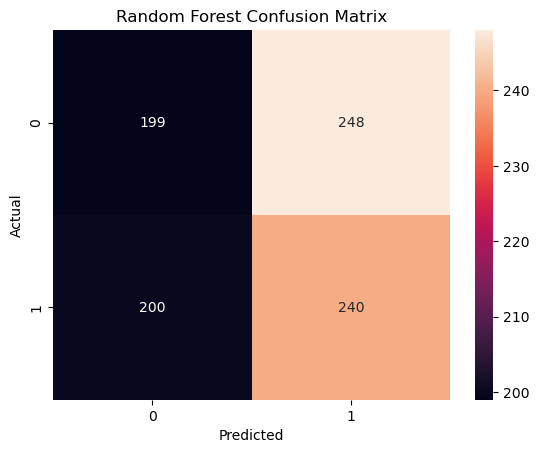

In [23]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm_rf, annot=True, fmt='d')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))

KNN Accuracy: 0.5366403607666291


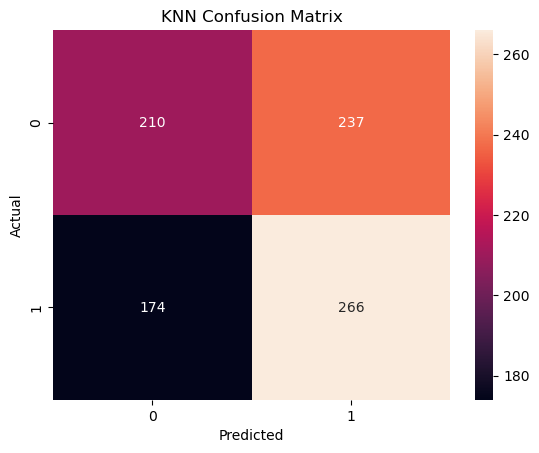

In [27]:
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure()
sns.heatmap(cm_knn, annot=True, fmt='d')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

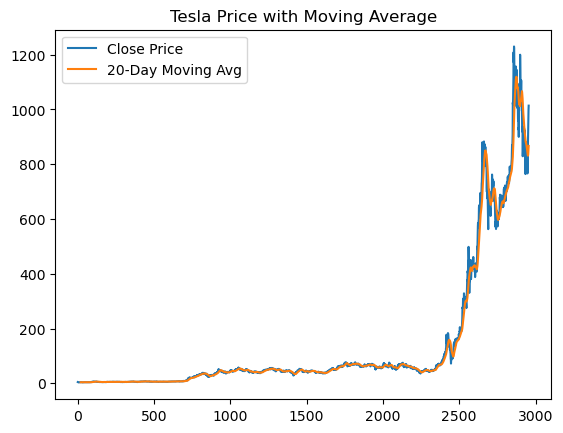

In [29]:
df['MA20'] = df['Close'].rolling(window=20).mean()
plt.figure()
plt.plot(df['Close'], label='Close Price')
plt.plot(df['MA20'], label='20-Day Moving Avg')
plt.legend()
plt.title("Tesla Price with Moving Average")
plt.show()

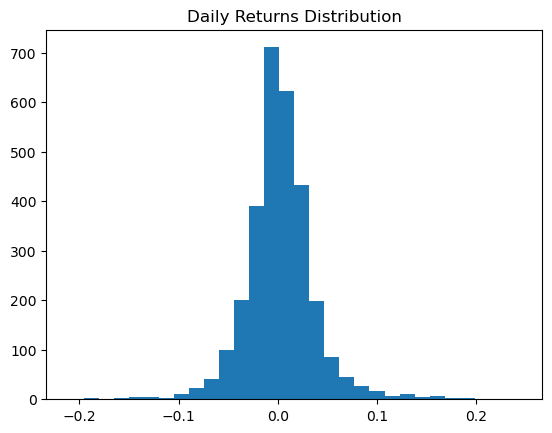

In [31]:
df['Daily_Return'] = df['Close'].pct_change()
plt.figure()
plt.hist(df['Daily_Return'].dropna(), bins=30)
plt.title("Daily Returns Distribution")
plt.show()